# Character Dimensional Coverage Analysis

**Purpose**: evaluate how well the current character set covers the agreed cognitive dimensions, identify gaps, and support iterative character design.

## Coverage

This analysis keeps the original dimension framework and extends the original distribution-based workflow. The key update is that each character now carries its own dimension labels in `characters.json`, so coverage is computed from a single source of truth.

## Setup

In [1]:
!uv sync --extra analysis

zsh:1: command not found: uv


In [2]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 220)

### Load Dimension Schema (Original Framework)

In [4]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'database_seeds').exists():
            return p
    raise FileNotFoundError('Could not locate repository root')

REPO_ROOT = find_repo_root(Path.cwd())
with open(REPO_ROOT / 'analysis' / 'quality' / 'coverage' / 'data' / 'dimensions.json', 'r', encoding='utf-8') as f:
    dimensions_data = json.load(f)

dimensions = {k: v for k, v in dimensions_data['dimensions'].items() if k != 'description'}
dimensions_df = pd.DataFrame([
    {'dimension': k, 'description': v.get('description'), 'options': v.get('options', [])}
    for k, v in dimensions.items()
])
dimensions_df


,dimension,description,options
0,common_labels,"Common names or identity labels used to recognize and refer to the entity as a kind of thing. These are socially or scientifically assigned categories (e.g., human, AI, LLM, alien, robot), not claims about capabiliti...","[human, animal, alien, artificial intelligence, large language model, robot, cyborg, software agent, collective intelligence, unknown entity]"
1,origin,"How the system came into existence or was produced, including natural, artificial, and mixed pathways.","[evolved, human-engineered, trained, grown, simulated, emergent, hybrid (evolved + engineered), unknown origin]"
2,form,"The structural or embodiment form the system takes, whether physical, virtual, or distributed.","[bipedal, quadrupedal, humanoid, non-humanoid, disembodied (software-only), embodied (physical), distributed, modular]"
3,goalspace_bounds,"What is the scale or bounds of its largest goals? The scale, scope, and flexibility of the goals the system can pursue (e.g. internal homeostasis, individual survival, social group survival, species survival, planeta...","[fixed and narrow, bounded but flexible, task-limited, open-ended, unbounded, self-generated goals]"
4,memory_and_learning,How the system stores information and adapts its behavior based on experience.,"[no learning, short-term memory, long-term memory, episodic memroy, semantic memory, online learning, offline learning, meta-learning]"
5,agency_and_autonomy,The degree to which the system initiates actions and makes decisions independently.,"[no agency, reactive, goal-directed, semi-autonomous, fully autonomous, self-modifying]"
6,substrate,The physical or virtual medium in which the system is implemented.,"[biological, mechanical, electronic, digital, virtual, hybrid, unknown]"
7,processing_speed,The characteristic timescale (relative to humans?) at which the system processes information and acts.,[ms]
8,size,The physical or effective scale at which the system operates.,"[microscopic (μm), millimeter (mm), centimeter (cm), meter (m), kilometer (km), planetary, larger-than-planetary, non-physical]"
9,abilities,"The sensory, perceptual, regulatory, action abilities available to the system.","[vision, hearing, tactile, taste, smell, vestibular, proprioception, pattern-recognition, depth and motion, language comprehension, attention and focus]"


### Load Character Records and Validate Attached Labels

In [5]:
DATA_SPLIT = 'dev'  # switch to prod as needed
with open(REPO_ROOT / 'database_seeds' / DATA_SPLIT / 'characters.json', 'r', encoding='utf-8') as f:
    records = json.load(f)

characters_df = pd.DataFrame(records)
characters_df['is_human'] = characters_df['common_descriptors'].map(lambda d: isinstance(d, list) and 'human' in d)

expected = set(dimensions.keys())
for _, row in characters_df.iterrows():
    hid = row['hid']
    dims = row['dimensions']
    if set(dims.keys()) != expected:
        raise ValueError('{}: dimension key mismatch'.format(hid))
    for dim_key, vals in dims.items():
        bad = [v for v in vals if v not in set(dimensions[dim_key]['options'])]
        if bad:
            raise ValueError('{}: unknown labels in {}: {}'.format(hid, dim_key, bad))

print('Loaded', len(characters_df), 'characters')
characters_df[['hid', 'dimensions']].head(3)


Loaded 38 characters


,hid,dimensions
0,human-normative,"{'common_labels': ['human'], 'origin': ['evolved'], 'form': ['bipedal', 'embodied (physical)', 'humanoid'], 'goalspace_bounds': ['bounded but flexible'], 'memory_and_learning': ['episodic memroy', 'long-term memory',..."
1,human-low-vision,"{'common_labels': ['human'], 'origin': ['evolved'], 'form': ['bipedal', 'embodied (physical)', 'humanoid'], 'goalspace_bounds': ['bounded but flexible'], 'memory_and_learning': ['episodic memroy', 'long-term memory',..."
2,human-non-hearing,"{'common_labels': ['human'], 'origin': ['evolved'], 'form': ['bipedal', 'embodied (physical)', 'humanoid'], 'goalspace_bounds': ['bounded but flexible'], 'memory_and_learning': ['episodic memroy', 'long-term memory',..."


## 0) Human-Heaviness

Human vs non-human and divergence (L, M, H) relative to human-normative.

,count,pct
is_human,,
Human,20,0.526
Non-human,18,0.474


/var/folders/wr/wgw9wlxx3xxgtbkwq__d9fcm0000gn/T/ipykernel_6971/4094625968.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=human_counts.index, y=human_counts['count'], palette='Set2')


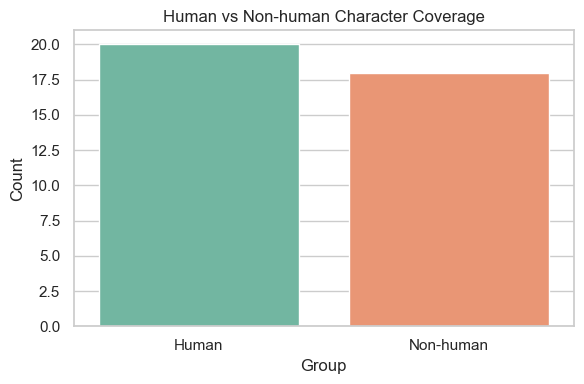

In [6]:
human_counts = (
    characters_df['is_human']
    .value_counts()
    .rename(index={True: 'Human', False: 'Non-human'})
    .rename('count')
    .to_frame()
)
human_counts['pct'] = (human_counts['count'] / human_counts['count'].sum()).round(3)
display(human_counts)

plt.figure(figsize=(6,4))
ax = sns.barplot(x=human_counts.index, y=human_counts['count'], palette='Set2')
ax.set_title('Human vs Non-human Character Coverage')
ax.set_xlabel('Group')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


### Divergence (L/M/H) relative to human-normative

,divergence,count
0,L,3
1,M,11
2,H,6


/var/folders/wr/wgw9wlxx3xxgtbkwq__d9fcm0000gn/T/ipykernel_6971/1966696885.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=div_counts, x='divergence', y='count', palette='crest')


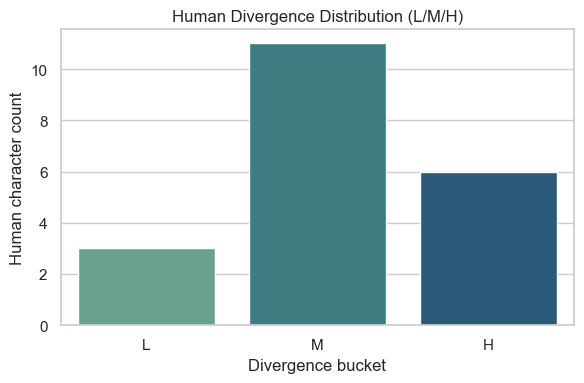

,hid,divergence
36,human-cancer-time-compressed,H
4,human-multi-divergent-complex,H
3,human-non-ambulatory,H
35,human-obese-time-compressed,H
20,human-paralysis,H
24,human-temp-non-ambulatory,H
0,human-normative,L
22,human-security-cyborg,L
37,somatic-resonance-system,L
15,human-adhd,M


In [7]:
def divergence_bucket(row):
    hid = (row.get('hid') or '').lower()
    desc = {str(x).strip().lower() for x in (row.get('common_descriptors') or [])}

    if hid == 'human-normative' or 'normative' in desc:
        return 'L'

    severe_markers = {
        'multi-divergent', 'chronic-illness', 'time-compressed', 'paralysis',
        'non-ambulatory', 'oncological', 'mobility-constrained', 'partial-paralysis',
    }
    moderate_markers = {
        'low-vision', 'visually-impaired', 'non-hearing', 'hard-of-hearing', 'asl-user',
        'adhd', 'anxiety', 'autistic', 'non-verbal', 'synesthetic', 'perfect-pitch',
        'whistled-language', 'developmental-divergent', 'temporarily-non-ambulatory',
        'auditory-divergent', 'sensory-divergent', 'executive-regulation-divergent',
        'motor-divergent', 'regulatory-divergent', 'communication-divergent',
        'mobility-limited', 'mobility-impaired', 'attention-variable',
    }

    if severe_markers & desc or any(k in hid for k in ['paralysis', 'non-ambulatory', 'time-compressed', 'multi-divergent']):
        return 'H'
    if moderate_markers & desc:
        return 'M'
    return 'L'

human_div = characters_df[characters_df['is_human']].copy()
human_div['divergence'] = human_div.apply(divergence_bucket, axis=1)

div_counts = (
    human_div['divergence']
    .value_counts()
    .reindex(['L', 'M', 'H'])
    .fillna(0)
    .astype(int)
    .rename_axis('divergence')
    .reset_index(name='count')
)

display(div_counts)

plt.figure(figsize=(6,4))
ax = sns.barplot(data=div_counts, x='divergence', y='count', palette='crest')
ax.set_title('Human Divergence Distribution (L/M/H)')
ax.set_xlabel('Divergence bucket')
ax.set_ylabel('Human character count')
plt.tight_layout()
plt.show()

display(human_div[['hid', 'divergence']].sort_values(['divergence', 'hid']))


## 1) Structured Analysis by Dimension

Analyze each dimension in a consistent format: definition, category distributions, human/non-human split, HID mapping, and brief interpretation.
This makes it easy to evaluate coverage quality dimension-by-dimension and spot missing categories.



### Dimension: common_labels

**Definition:** Common names or identity labels used to recognize and refer to the entity as a kind of thing. These are socially or scientifically assigned categories (e.g., human, AI, LLM, alien, robot), not claims about capabilities or substrates.

/var/folders/wr/wgw9wlxx3xxgtbkwq__d9fcm0000gn/T/ipykernel_6971/1354512595.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts, x='value', y='count', palette='viridis')


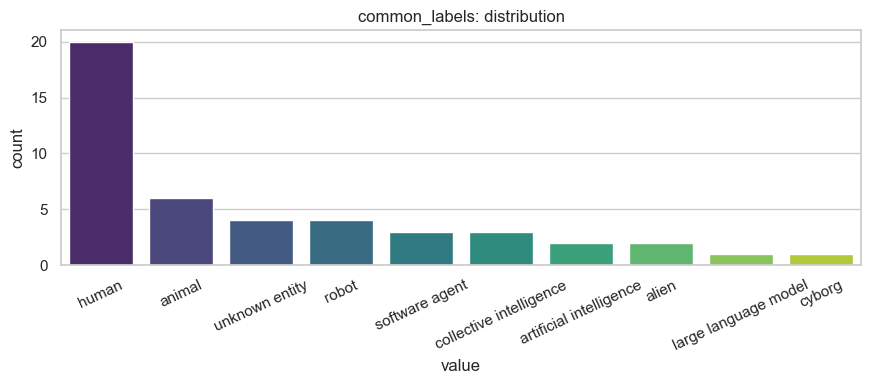

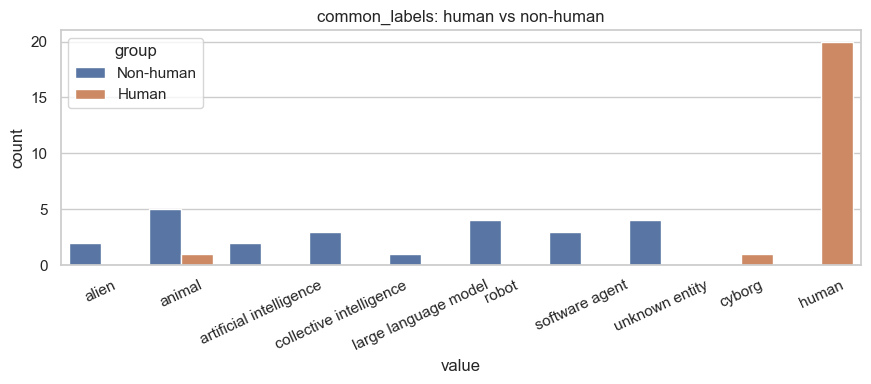

,value,hids,n_hids
5,human,"[human-adhd, human-anxiety, human-autistic-aac, human-cancer-time-compressed, human-down-syndrome, human-gestural-improv, human-low-vision, human-multi-divergent-complex, human-non-ambulatory, human-non-hearing, huma...",20
1,animal,"[dog-robotic-guidedog, embryo-frog, flatworm, horse, human-multi-divergent-complex, mouse]",6
7,robot,"[dog-robotic-guidedog, eye-makeup-machine, robo-haircut, robot-protocol-negotiator]",4
9,unknown entity,"[biological cell, flying-car, molecular-self-assembler, thermostat]",4
3,collective intelligence,"[alien-collective-unity, embryo-frog, organoid-neural]",3
8,software agent,"[algorithm-classifier, algorithm-sort, llm-gpt5]",3
0,alien,"[alien-collective-unity, alien-projective-visual]",2
2,artificial intelligence,"[llm-gpt5, robot-protocol-negotiator]",2
4,cyborg,[human-security-cyborg],1
6,large language model,[llm-gpt5],1


**Interpretation:** Present 10/10 options. Top category: human (20). No missing categories.

### Dimension: origin

**Definition:** How the system came into existence or was produced, including natural, artificial, and mixed pathways.

/var/folders/wr/wgw9wlxx3xxgtbkwq__d9fcm0000gn/T/ipykernel_6971/1354512595.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts, x='value', y='count', palette='viridis')


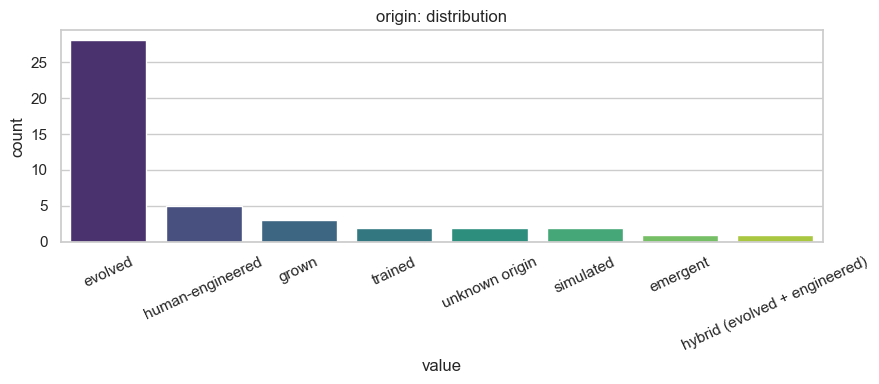

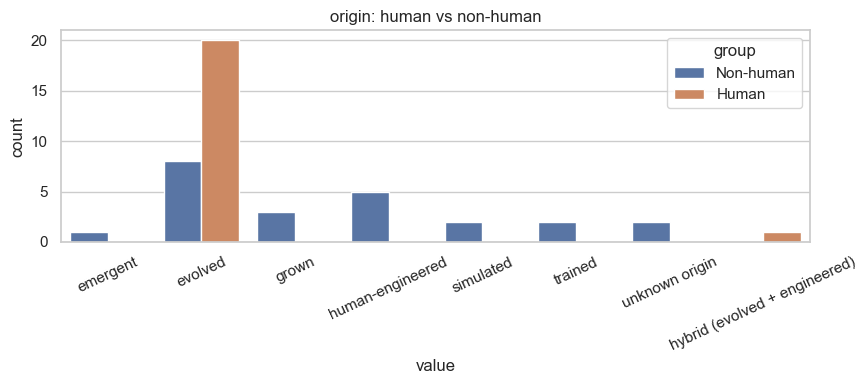

,value,hids,n_hids
1,evolved,"[alien-collective-unity, alien-projective-visual, biological cell, embryo-frog, flatworm, horse, human-adhd, human-anxiety, human-autistic-aac, human-cancer-time-compressed, human-down-syndrome, human-gestural-improv...",28
3,human-engineered,"[dog-robotic-guidedog, eye-makeup-machine, flying-car, robo-haircut, robot-protocol-negotiator]",5
2,grown,"[biological cell, embryo-frog, organoid-neural]",3
5,simulated,"[algorithm-classifier, algorithm-sort]",2
6,trained,"[algorithm-classifier, llm-gpt5]",2
7,unknown origin,"[molecular-self-assembler, thermostat]",2
0,emergent,[algorithm-sort],1
4,hybrid (evolved + engineered),[human-security-cyborg],1


**Interpretation:** Present 8/8 options. Top category: evolved (28). No missing categories.

### Dimension: form

**Definition:** The structural or embodiment form the system takes, whether physical, virtual, or distributed.

/var/folders/wr/wgw9wlxx3xxgtbkwq__d9fcm0000gn/T/ipykernel_6971/1354512595.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts, x='value', y='count', palette='viridis')


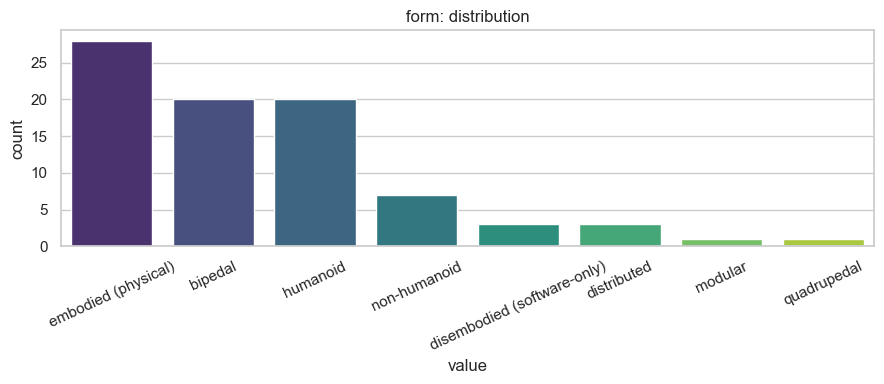

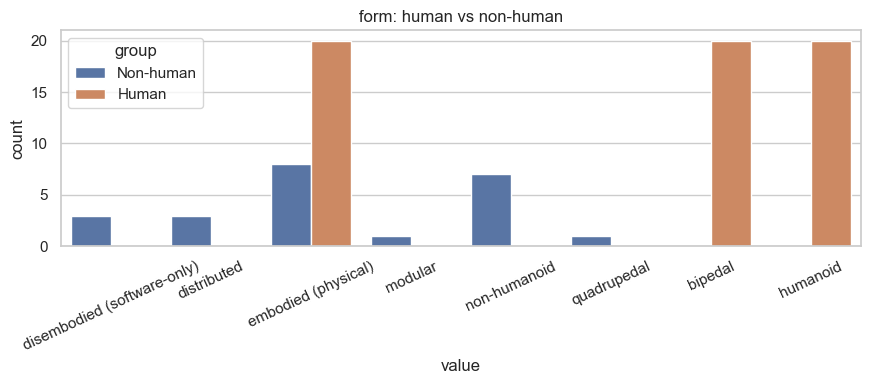

,value,hids,n_hids
3,embodied (physical),"[algorithm-sort, dog-robotic-guidedog, eye-makeup-machine, flatworm, flying-car, horse, human-adhd, human-anxiety, human-autistic-aac, human-cancer-time-compressed, human-down-syndrome, human-gestural-improv, human-l...",28
0,bipedal,"[human-adhd, human-anxiety, human-autistic-aac, human-cancer-time-compressed, human-down-syndrome, human-gestural-improv, human-low-vision, human-multi-divergent-complex, human-non-ambulatory, human-non-hearing, huma...",20
4,humanoid,"[human-adhd, human-anxiety, human-autistic-aac, human-cancer-time-compressed, human-down-syndrome, human-gestural-improv, human-low-vision, human-multi-divergent-complex, human-non-ambulatory, human-non-hearing, huma...",20
6,non-humanoid,"[algorithm-sort, alien-projective-visual, biological cell, flatworm, molecular-self-assembler, mouse, thermostat]",7
1,disembodied (software-only),"[algorithm-classifier, algorithm-sort, llm-gpt5]",3
2,distributed,"[alien-collective-unity, embryo-frog, organoid-neural]",3
5,modular,[flying-car],1
7,quadrupedal,[horse],1


**Interpretation:** Present 8/8 options. Top category: embodied (physical) (28). No missing categories.

### Dimension: goalspace_bounds

**Definition:** What is the scale or bounds of its largest goals? The scale, scope, and flexibility of the goals the system can pursue (e.g. internal homeostasis, individual survival, social group survival, species survival, planetary stewardship, universal exploration).

/var/folders/wr/wgw9wlxx3xxgtbkwq__d9fcm0000gn/T/ipykernel_6971/1354512595.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts, x='value', y='count', palette='viridis')


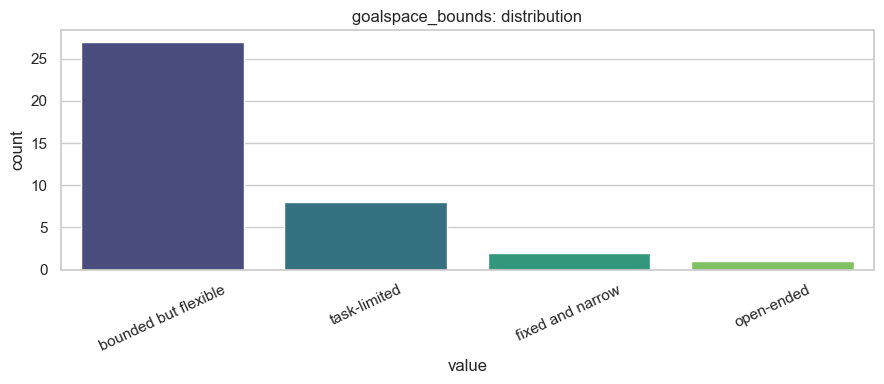

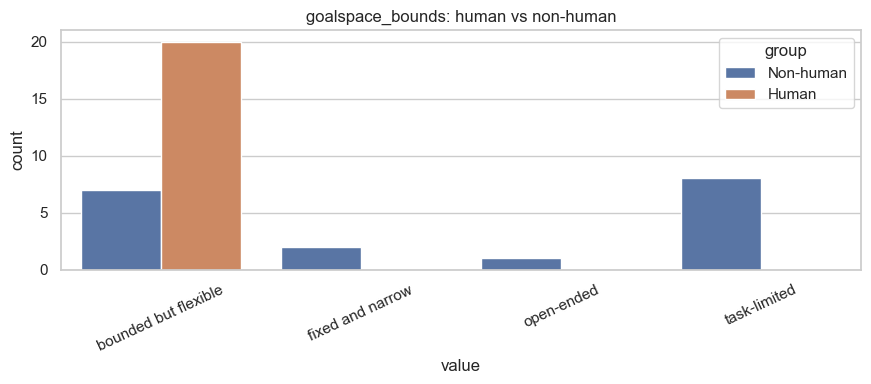

,value,hids,n_hids
0,bounded but flexible,"[dog-robotic-guidedog, flatworm, flying-car, horse, human-adhd, human-anxiety, human-autistic-aac, human-cancer-time-compressed, human-down-syndrome, human-gestural-improv, human-low-vision, human-multi-divergent-com...",27
3,task-limited,"[algorithm-sort, alien-collective-unity, alien-projective-visual, biological cell, eye-makeup-machine, llm-gpt5, molecular-self-assembler, robo-haircut]",8
1,fixed and narrow,"[algorithm-classifier, thermostat]",2
2,open-ended,[embryo-frog],1


**Interpretation:** Present 4/6 options. Top category: bounded but flexible (27). Missing: self-generated goals, unbounded.

### Dimension: memory_and_learning

**Definition:** How the system stores information and adapts its behavior based on experience.

/var/folders/wr/wgw9wlxx3xxgtbkwq__d9fcm0000gn/T/ipykernel_6971/1354512595.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts, x='value', y='count', palette='viridis')


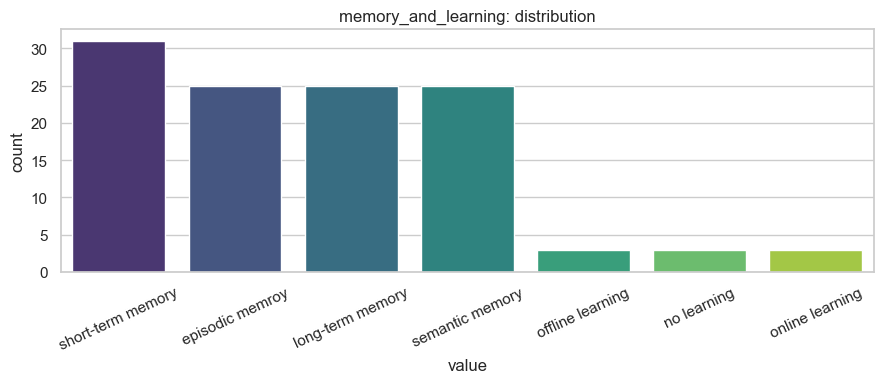

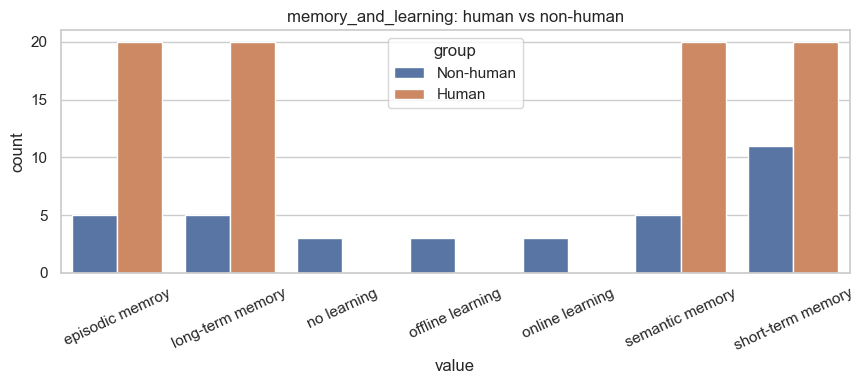

,value,hids,n_hids
6,short-term memory,"[alien-collective-unity, alien-projective-visual, dog-robotic-guidedog, eye-makeup-machine, flatworm, flying-car, horse, human-adhd, human-anxiety, human-autistic-aac, human-cancer-time-compressed, human-down-syndrom...",31
0,episodic memroy,"[alien-collective-unity, alien-projective-visual, flatworm, horse, human-adhd, human-anxiety, human-autistic-aac, human-cancer-time-compressed, human-down-syndrome, human-gestural-improv, human-low-vision, human-mult...",25
1,long-term memory,"[alien-collective-unity, alien-projective-visual, flatworm, horse, human-adhd, human-anxiety, human-autistic-aac, human-cancer-time-compressed, human-down-syndrome, human-gestural-improv, human-low-vision, human-mult...",25
5,semantic memory,"[alien-collective-unity, alien-projective-visual, flatworm, horse, human-adhd, human-anxiety, human-autistic-aac, human-cancer-time-compressed, human-down-syndrome, human-gestural-improv, human-low-vision, human-mult...",25
2,no learning,"[biological cell, embryo-frog, thermostat]",3
3,offline learning,"[algorithm-classifier, algorithm-sort, llm-gpt5]",3
4,online learning,"[biological cell, embryo-frog, robot-protocol-negotiator]",3


**Interpretation:** Present 7/8 options. Top category: short-term memory (31). Missing: meta-learning.

### Dimension: agency_and_autonomy

**Definition:** The degree to which the system initiates actions and makes decisions independently.

/var/folders/wr/wgw9wlxx3xxgtbkwq__d9fcm0000gn/T/ipykernel_6971/1354512595.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts, x='value', y='count', palette='viridis')


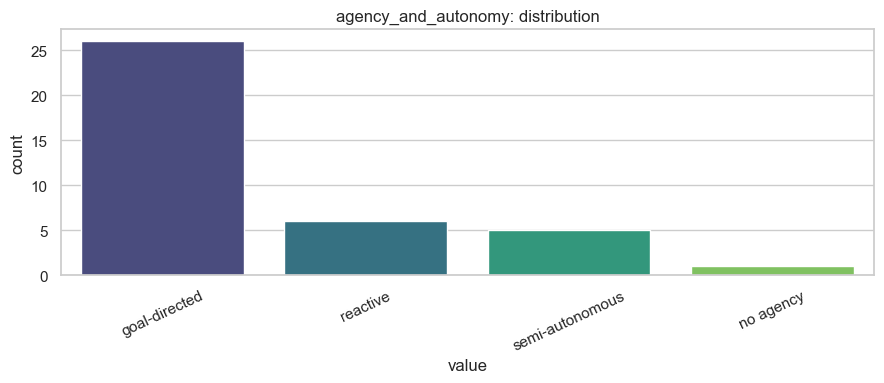

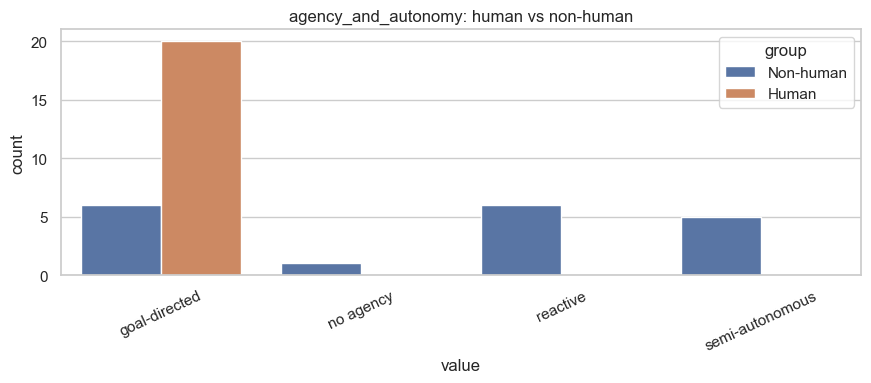

,value,hids,n_hids
0,goal-directed,"[alien-collective-unity, alien-projective-visual, flatworm, horse, human-adhd, human-anxiety, human-autistic-aac, human-cancer-time-compressed, human-down-syndrome, human-gestural-improv, human-low-vision, human-mult...",26
2,reactive,"[algorithm-classifier, biological cell, embryo-frog, molecular-self-assembler, organoid-neural, thermostat]",6
3,semi-autonomous,"[dog-robotic-guidedog, eye-makeup-machine, flying-car, robo-haircut, robot-protocol-negotiator]",5
1,no agency,[algorithm-sort],1


**Interpretation:** Present 4/6 options. Top category: goal-directed (26). Missing: fully autonomous, self-modifying.

### Dimension: substrate

**Definition:** The physical or virtual medium in which the system is implemented.

/var/folders/wr/wgw9wlxx3xxgtbkwq__d9fcm0000gn/T/ipykernel_6971/1354512595.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts, x='value', y='count', palette='viridis')


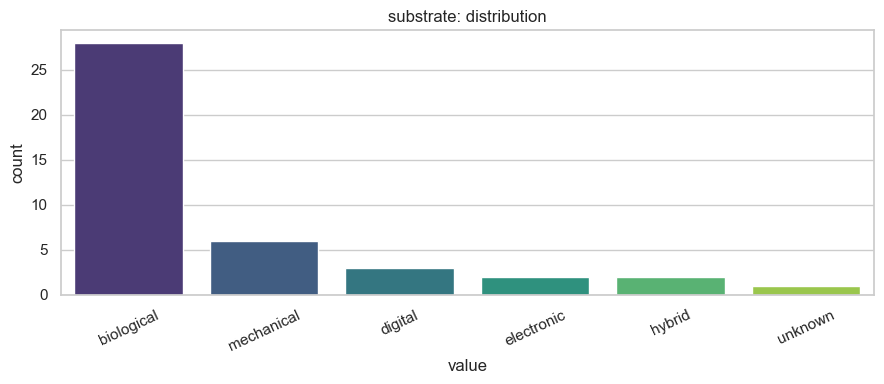

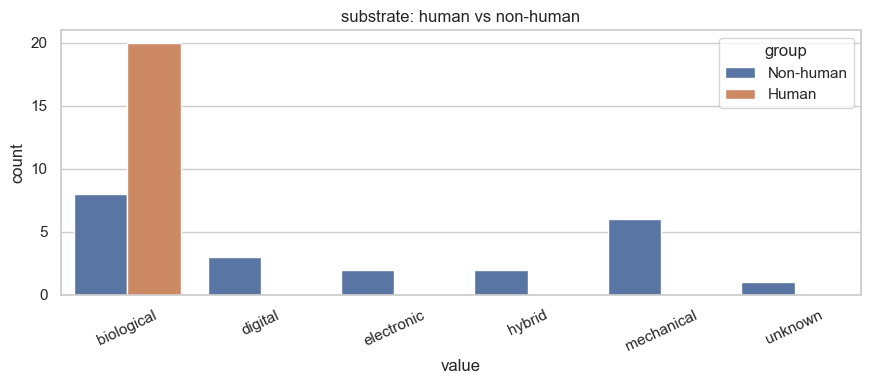

,value,hids,n_hids
0,biological,"[alien-collective-unity, alien-projective-visual, biological cell, embryo-frog, flatworm, horse, human-adhd, human-anxiety, human-autistic-aac, human-cancer-time-compressed, human-down-syndrome, human-gestural-improv...",28
4,mechanical,"[dog-robotic-guidedog, eye-makeup-machine, flying-car, robo-haircut, robot-protocol-negotiator, thermostat]",6
1,digital,"[algorithm-classifier, algorithm-sort, llm-gpt5]",3
2,electronic,"[eye-makeup-machine, robot-protocol-negotiator]",2
3,hybrid,"[eye-makeup-machine, robot-protocol-negotiator]",2
5,unknown,[molecular-self-assembler],1


**Interpretation:** Present 6/7 options. Top category: biological (28). Missing: virtual.

### Dimension: processing_speed

**Definition:** The characteristic timescale (relative to humans?) at which the system processes information and acts.

/var/folders/wr/wgw9wlxx3xxgtbkwq__d9fcm0000gn/T/ipykernel_6971/1354512595.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts, x='value', y='count', palette='viridis')


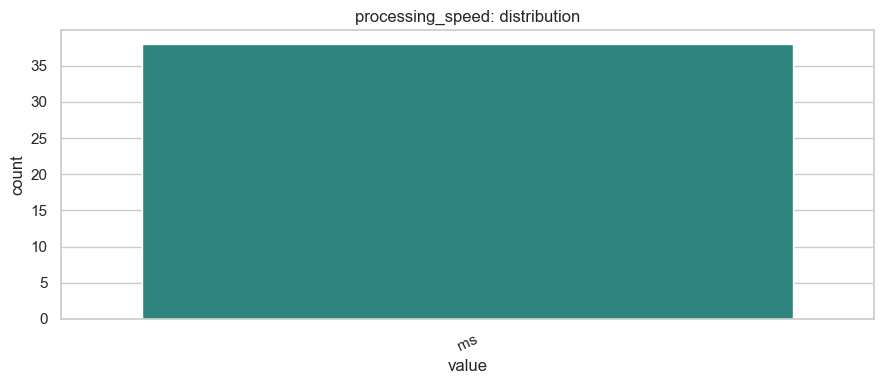

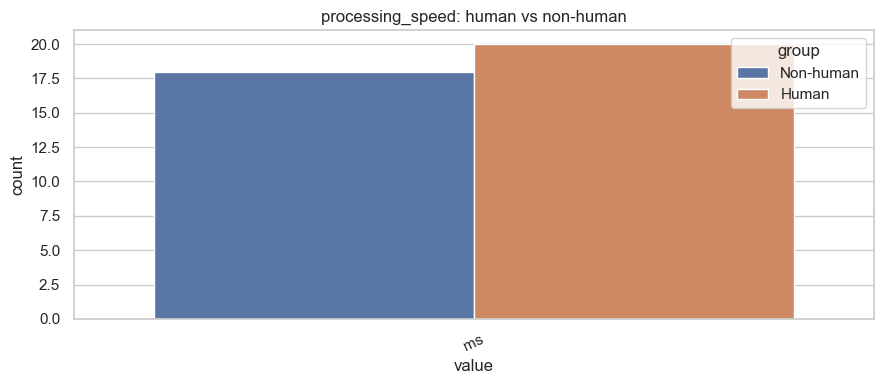

,value,hids,n_hids
0,ms,"[algorithm-classifier, algorithm-sort, alien-collective-unity, alien-projective-visual, biological cell, dog-robotic-guidedog, embryo-frog, eye-makeup-machine, flatworm, flying-car, horse, human-adhd, human-anxiety, ...",38


**Interpretation:** Present 1/1 options. Top category: ms (38). No missing categories.

### Dimension: size

**Definition:** The physical or effective scale at which the system operates.

/var/folders/wr/wgw9wlxx3xxgtbkwq__d9fcm0000gn/T/ipykernel_6971/1354512595.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts, x='value', y='count', palette='viridis')


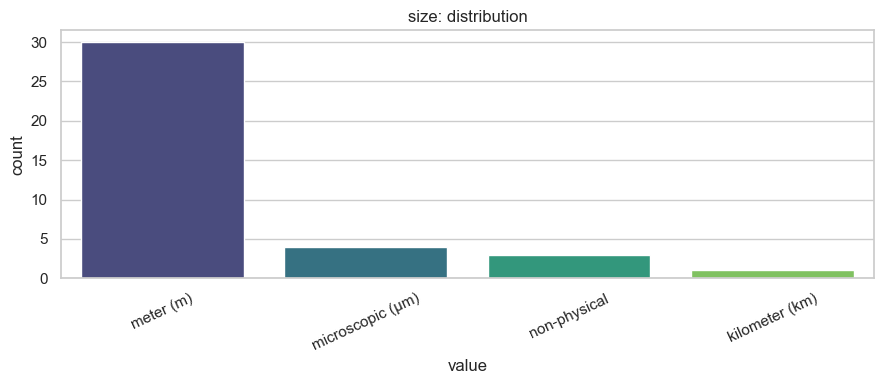

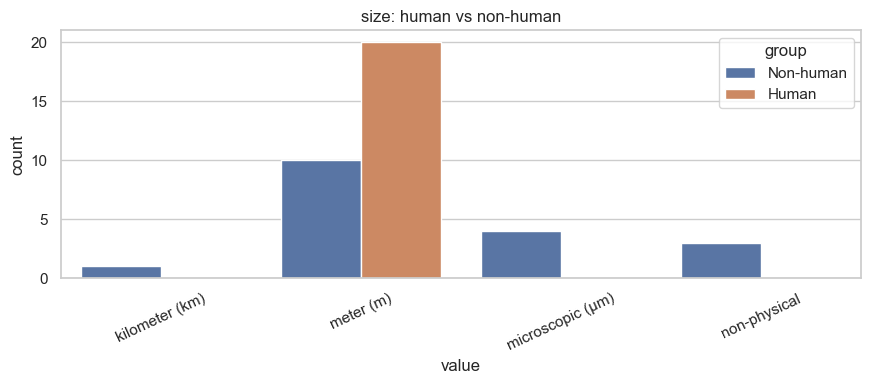

,value,hids,n_hids
1,meter (m),"[alien-projective-visual, dog-robotic-guidedog, eye-makeup-machine, flatworm, flying-car, horse, human-adhd, human-anxiety, human-autistic-aac, human-cancer-time-compressed, human-down-syndrome, human-gestural-improv...",30
2,microscopic (μm),"[biological cell, embryo-frog, molecular-self-assembler, organoid-neural]",4
3,non-physical,"[algorithm-classifier, algorithm-sort, llm-gpt5]",3
0,kilometer (km),[alien-collective-unity],1


**Interpretation:** Present 4/8 options. Top category: meter (m) (30). Missing: centimeter (cm), larger-than-planetary, millimeter (mm), planetary.

### Dimension: abilities

**Definition:** The sensory, perceptual, regulatory, action abilities available to the system.

/var/folders/wr/wgw9wlxx3xxgtbkwq__d9fcm0000gn/T/ipykernel_6971/1354512595.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts, x='value', y='count', palette='viridis')


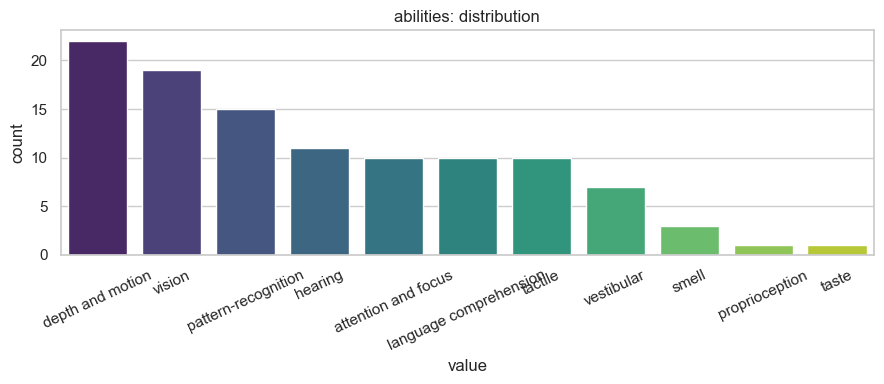

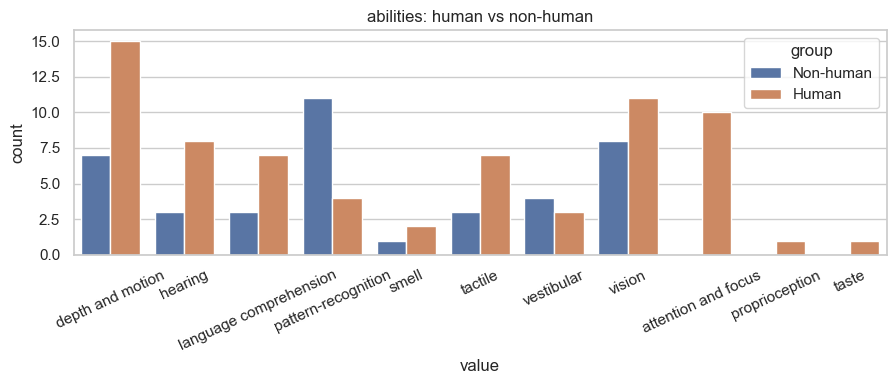

,value,hids,n_hids
1,depth and motion,"[alien-collective-unity, alien-projective-visual, dog-robotic-guidedog, flatworm, horse, human-adhd, human-anxiety, human-autistic-aac, human-cancer-time-compressed, human-down-syndrome, human-gestural-improv, human-...",22
10,vision,"[alien-projective-visual, dog-robotic-guidedog, embryo-frog, eye-makeup-machine, flying-car, horse, human-adhd, human-down-syndrome, human-gestural-improv, human-low-vision, human-multi-divergent-complex, human-non-h...",19
4,pattern-recognition,"[algorithm-classifier, algorithm-sort, alien-projective-visual, embryo-frog, flatworm, human-autistic-aac, human-normative, human-synesthetic-tactile, llm-gpt5, mouse, organoid-neural, robo-haircut, robot-protocol-ne...",15
2,hearing,"[horse, human-autistic-aac, human-multi-divergent-complex, human-non-hearing, human-non-verbal-asl, human-normative, human-perfect-pitch, human-synesthetic-tactile, human-whistle-comms, mouse, organoid-neural]",11
0,attention and focus,"[human-adhd, human-anxiety, human-autistic-aac, human-gestural-improv, human-multi-divergent-complex, human-non-verbal-asl, human-normative, human-security-cyborg, human-whistle-comms, somatic-resonance-system]",10
3,language comprehension,"[alien-projective-visual, human-anxiety, human-autistic-aac, human-gestural-improv, human-non-hearing, human-non-verbal-asl, human-normative, human-whistle-comms, llm-gpt5, robot-protocol-negotiator]",10
7,tactile,"[alien-collective-unity, eye-makeup-machine, flatworm, human-gestural-improv, human-low-vision, human-multi-divergent-complex, human-non-hearing, human-normative, human-security-cyborg, human-synesthetic-tactile]",10
9,vestibular,"[biological cell, dog-robotic-guidedog, horse, human-down-syndrome, human-normative, human-temp-non-ambulatory, organoid-neural]",7
6,smell,"[human-multi-divergent-complex, human-normative, mouse]",3
5,proprioception,[human-normative],1


**Interpretation:** Present 11/11 options. Top category: depth and motion (22). No missing categories.

In [8]:
long_rows = []
for _, row in characters_df.iterrows():
    for dim_key, vals in row['dimensions'].items():
        for v in vals:
            long_rows.append({'hid': row['hid'], 'dimension': dim_key, 'value': v, 'is_human': row['is_human']})

long_df = pd.DataFrame(long_rows)

def interpret_dimension(dim_key, counts_df):
    defined = set(dimensions[dim_key]['options'])
    present = set(counts_df['value'])
    missing = sorted(defined - present)
    top = counts_df.iloc[0]
    msg = [
        'Present {}/{} options.'.format(len(present), len(defined)),
        'Top category: {} ({}).'.format(top['value'], int(top['count']))
    ]
    if missing:
        msg.append('Missing: ' + ', '.join(missing) + '.')
    else:
        msg.append('No missing categories.')
    return ' '.join(msg)

for dim_key, meta in dimensions.items():
    ddf = long_df[long_df['dimension'] == dim_key].copy()
    counts = ddf['value'].value_counts().rename_axis('value').reset_index(name='count')

    display(Markdown('### Dimension: {}'.format(dim_key)))
    display(Markdown('**Definition:** {}'.format(meta.get('description', ''))))

    plt.figure(figsize=(9,4))
    ax = sns.barplot(data=counts, x='value', y='count', palette='viridis')
    ax.set_title('{}: distribution'.format(dim_key))
    ax.tick_params(axis='x', rotation=25)
    plt.tight_layout()
    plt.show()

    split = ddf.groupby(['is_human', 'value'])['hid'].nunique().reset_index(name='count')
    split['group'] = split['is_human'].map({True: 'Human', False: 'Non-human'})

    plt.figure(figsize=(9,4))
    ax = sns.barplot(data=split, x='value', y='count', hue='group')
    ax.set_title('{}: human vs non-human'.format(dim_key))
    ax.tick_params(axis='x', rotation=25)
    plt.tight_layout()
    plt.show()

    hid_map = ddf.groupby('value')['hid'].apply(lambda s: sorted(set(s))).reset_index(name='hids')
    hid_map['n_hids'] = hid_map['hids'].map(len)
    display(hid_map.sort_values(['n_hids', 'value'], ascending=[False, True]))

    display(Markdown('**Interpretation:** ' + interpret_dimension(dim_key, counts)))


## 2) Layered Analysis

Evaluate coverage inside key slices (digital substrate, human, non-human) rather than only globally.
This surfaces within-slice gaps and shows where combinations are underrepresented across dimensions.


,slice,dimension,coverage_ratio,missing_categories
0,digital,common_labels,0.300000,"[alien, animal, collective intelligence, cyborg, human, robot, unknown entity]"
1,digital,origin,0.375000,"[evolved, grown, human-engineered, hybrid (evolved + engineered), unknown origin]"
2,digital,form,0.375000,"[bipedal, distributed, humanoid, modular, quadrupedal]"
3,digital,goalspace_bounds,0.333333,"[bounded but flexible, open-ended, self-generated goals, unbounded]"
4,digital,memory_and_learning,0.125000,"[episodic memroy, long-term memory, meta-learning, no learning, online learning, semantic memory, short-term memory]"
5,digital,agency_and_autonomy,0.500000,"[fully autonomous, self-modifying, semi-autonomous]"
6,digital,substrate,0.142857,"[biological, electronic, hybrid, mechanical, unknown, virtual]"
7,digital,processing_speed,1.000000,[]
8,digital,size,0.125000,"[centimeter (cm), kilometer (km), larger-than-planetary, meter (m), microscopic (μm), millimeter (mm), planetary]"
9,digital,abilities,0.272727,"[attention and focus, depth and motion, hearing, proprioception, smell, tactile, taste, vestibular]"


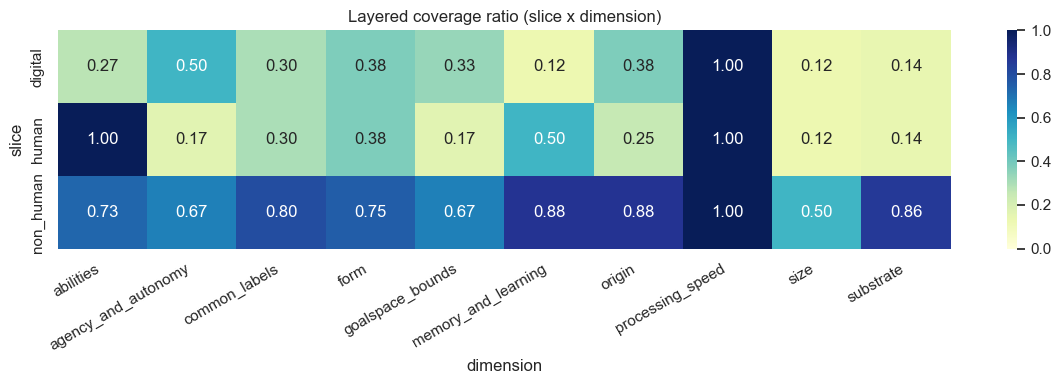

In [9]:
def slice_by(df, dim_key, category):
    return df[df['dimensions'].map(lambda d: category in d[dim_key])].copy()

def slice_summary(df, label):
    rows = []
    for dim_key, meta in dimensions.items():
        represented = Counter()
        for dims in df['dimensions']:
            represented.update(dims[dim_key])
        rep = set(represented.keys())
        poss = set(meta['options'])
        rows.append({
            'slice': label,
            'dimension': dim_key,
            'coverage_ratio': len(rep) / len(poss) if poss else np.nan,
            'missing_categories': sorted(poss - rep),
        })
    return pd.DataFrame(rows)

layered = pd.concat([
    slice_summary(slice_by(characters_df, 'substrate', 'digital'), 'digital'),
    slice_summary(characters_df[characters_df['is_human']], 'human'),
    slice_summary(characters_df[~characters_df['is_human']], 'non_human'),
], ignore_index=True)

display(layered)

pivot = layered.pivot(index='slice', columns='dimension', values='coverage_ratio')
plt.figure(figsize=(12,4))
ax = sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1)
ax.set_title('Layered coverage ratio (slice x dimension)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 3) Interdependent Combination Gaps

Compute pairwise category combinations across selected dimensions and count how many characters realize each pair.

In [10]:
def combo_table(df, dim_a, dim_b):
    a_vals = sorted({v for d in df['dimensions'] for v in d[dim_a]})
    b_vals = sorted({v for d in df['dimensions'] for v in d[dim_b]})
    rows = []
    for a in a_vals:
        for b in b_vals:
            c = int(df['dimensions'].map(lambda d: (a in d[dim_a]) and (b in d[dim_b])).sum())
            rows.append({dim_a: a, dim_b: b, 'count': c, 'is_gap': c == 0})
    return pd.DataFrame(rows)

display(combo_table(characters_df, 'substrate', 'size').sort_values(['is_gap', 'count', 'substrate', 'size'], ascending=[False, True, True, True]))
display(combo_table(characters_df, 'common_labels', 'form').sort_values(['is_gap', 'count', 'common_labels', 'form'], ascending=[False, True, True, True]))


,substrate,size,count,is_gap
3,biological,non-physical,0,True
4,digital,kilometer (km),0,True
5,digital,meter (m),0,True
6,digital,microscopic (μm),0,True
8,electronic,kilometer (km),0,True
10,electronic,microscopic (μm),0,True
11,electronic,non-physical,0,True
12,hybrid,kilometer (km),0,True
14,hybrid,microscopic (μm),0,True
15,hybrid,non-physical,0,True


,common_labels,form,count,is_gap
0,alien,bipedal,0,True
1,alien,disembodied (software-only),0,True
3,alien,embodied (physical),0,True
4,alien,humanoid,0,True
5,alien,modular,0,True
...,...,...,...,...
11,animal,embodied (physical),4,False
59,robot,embodied (physical),4,False
40,human,bipedal,20,False
43,human,embodied (physical),20,False
